In [2]:
import pandas as pd
import numpy as np
import joblib
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Sentence Transformers để tạo embeddings
from sentence_transformers import SentenceTransformer

# Scikit-learn cho mô hình và đánh giá
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [ ]:
try:
    df = pd.read_csv('data/mail_data.csv', nrows=9000)
    print("Tải dữ liệu thành công!")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'data/raw_data.csv'.")
    print("Hãy chắc chắn rằng bạn đã tạo thư mục 'data' và đặt tệp dữ liệu vào đó.")

df.head()

Tải dữ liệu thành công!


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Ánh xạ 'ham' -> 0 và 'spam' -> 1
df['label'] = df['Category'].map({'ham': 0, 'spam': 1})

# Xóa các dòng có giá trị thiếu (nếu có)
df.dropna(inplace=True)

# Chọn các cột cần thiết
data = df[['Message', 'label']]

print("Dữ liệu sau khi xử lý:")
data.head()

Dữ liệu sau khi xử lý:


,Message,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [5]:
# lây embeddings từ file đã lưu
embeddings = joblib.load('data/embeddings.pkl')
# Gán X (features) và y (target)
X = embeddings
y = data['label'].values

In [6]:
print("Kích thước của X:", X.shape)
print("Kích thước của y:", y.shape)

Kích thước của X: (6574, 384)
Kích thước của y: (6574,)


In [10]:
# Chia dữ liệu thành tập train và test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuyển đổi dữ liệu sang dạng PyTorch Tensor
# (Giữ nguyên code từ trước)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Tạo DataLoader để quản lý batch
# (Giữ nguyên code từ trước)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

In [8]:
# Class Feed Forward Neural Network với Residual Connection
class FeedForwardSpamClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int, hidden_dim2: int, output_dim: int):
        super(FeedForwardSpamClassifier, self).__init__()
        
        # Do đó, `hidden_dim1` phải bằng `input_dim`.
        if input_dim != hidden_dim1:
            raise ValueError(f"Để sử dụng Residual Connection, input_dim ({input_dim}) "
                             f"phải bằng hidden_dim1 ({hidden_dim1}).")

        # Khối Feed-Forward đầu tiên, nơi chúng ta sẽ áp dụng residual connection
        self.feed_forward_block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.Mish(),
            nn.Linear(hidden_dim1, hidden_dim1),
        )
        
        # Khối MLP 
        self.second_block = nn.Sequential(
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Mish(),
            nn.Linear(hidden_dim2, hidden_dim2),
        )

        # Lớp output để ra quyết định
        self.output_layer = nn.Linear(hidden_dim2, output_dim)
        
        # Lớp chuẩn hóa (Layer Normalization) có thể giúp ổn định việc training với residual connections
        self.layer_norm = nn.LayerNorm(hidden_dim1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Lưu lại giá trị đầu vào ban đầu cho residual connection
        residual = x 
        
        # Dữ liệu đi qua khối feed-forward đầu tiên
        out = self.feed_forward_block(x)
        out = out + residual
        out = self.layer_norm(out) # Áp dụng LayerNorm để ổn định
        
        # Tiếp tục đi qua khối thứ hai
        out = self.second_block(out)
        
        # Lớp đầu ra
        out = self.output_layer(out)
        return out

In [12]:
# --- THAY ĐỔI KHI KHỞI TẠO MODEL ---
INPUT_DIM = X_train.shape[1]
HIDDEN_DIM_1 = INPUT_DIM
HIDDEN_DIM_2 = 128
OUTPUT_DIM = 1
LEARNING_RATE = 0.001
EPOCHS = 35 


In [13]:
# Tải lại mô hình để kiểm tra
loaded_model = FeedForwardSpamClassifier(
    input_dim=INPUT_DIM, 
    hidden_dim1=HIDDEN_DIM_1, 
    hidden_dim2=HIDDEN_DIM_2,
    output_dim=OUTPUT_DIM
)
MODEL_PATH = 'checkpoints/ff_spam_classifier_model_test.pth' # Dùng đúng tên file đã lưu
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

FeedForwardSpamClassifier(
  (feed_forward_block): Sequential(
    (0): Linear(in_features=384, out_features=384, bias=True)
    (1): Mish()
    (2): Linear(in_features=384, out_features=384, bias=True)
  )
  (second_block): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): Mish()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
  (layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)

In [16]:
print("\nĐánh giá mô hình trên tập test...")
loaded_model.eval()
with torch.no_grad():
    y_predicted_logits = loaded_model(X_test_tensor)
    y_predicted_prob = torch.sigmoid(y_predicted_logits)
    y_predicted_labels = (y_predicted_prob > 0.4).int()

y_predicted_labels = y_predicted_labels.cpu().numpy()


Đánh giá mô hình trên tập test...



Accuracy: 0.8221

Classification Report:
              precision    recall  f1-score   support

         Ham       0.92      0.85      0.89      1082
        Spam       0.50      0.68      0.57       233

    accuracy                           0.82      1315
   macro avg       0.71      0.77      0.73      1315
weighted avg       0.85      0.82      0.83      1315



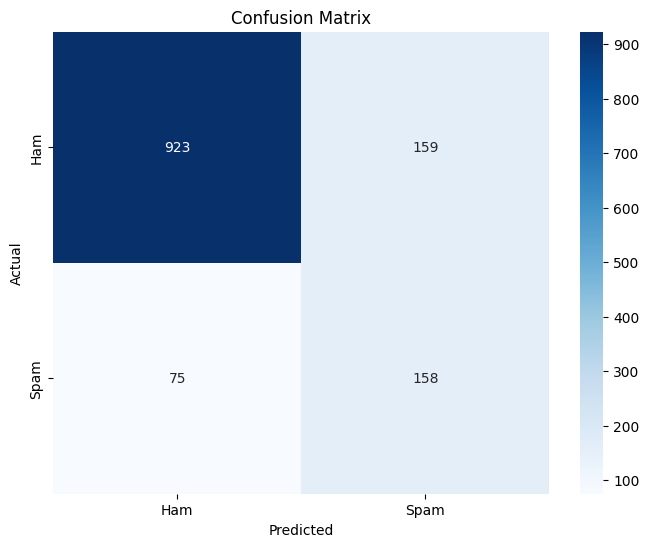

In [17]:
print(f"\nAccuracy: {accuracy_score(y_test, y_predicted_labels):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_predicted_labels, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()